# 🌱 AgriMesh — Train the crop-disease model (Kaggle **or** Colab)

Enable GPU first: **Kaggle** → Settings ⚙️ → Accelerator → GPU T4 x2 · **Colab** → Runtime → Change runtime type → GPU.

> 💡 **On Kaggle, use *Save Version → Save & Run All (Commit)*.** It runs on Kaggle's
> servers in the background (up to 12h) — you can close the tab or your laptop and it
> keeps training. This removes the disconnect problem entirely. Grab `web_model.zip`
> from the Output panel when it finishes.

Self-contained: you only upload the dataset zip. The notebook normalizes the
134 messy folders → 107 clean classes, trains MobileNetV2, and exports a
~9MB TensorFlow.js model that drops straight into `frontend/models/`.

Run the cells top to bottom.

> ⚠️ **DO NOT refresh or close this tab while training (cells 7–8).** A refresh
> disconnects the runtime and wipes the model from memory. This notebook now
> saves the best model to your Drive automatically, and a **quality gate**
> (cell 8b) refuses to export an untrained model — so even a disconnect only
> costs you a re-run of cells 6–8, never a broken download.

## 1. Check GPU

In [1]:
import tensorflow as tf
print('TF', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU:', gpus or 'NONE — set Runtime > Change runtime type > GPU!')

TF 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Install the TF.js converter
We force **legacy Keras (Keras 2)** — the TensorFlow.js converter is reliable
with it and flaky with Keras 3. Ignore pip dependency warnings.

In [2]:
!pip install -q tensorflowjs tf_keras
print('installed — RESTART NOT NEEDED, just continue')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.2/15.2 MB 95.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 96.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ray 2.55.1 requires packaging>=24.2, but you have packaging 23.2 wh

## 3. Get the dataset  (works on **Kaggle** and **Colab**)
- **Kaggle (recommended):** add your dataset via *+ Add Input* (right panel). It
  appears under `/kaggle/input/…` — this cell finds it automatically. No Drive, no unzip.
- **Colab:** upload `archive (1).zip` to My Drive root; this cell mounts Drive and unzips.

`WORK` = where outputs go (checkpoint, model). On Kaggle that's `/kaggle/working`.

In [3]:
import os, glob, zipfile
IS_KAGGLE = os.path.exists('/kaggle')
WORK   = '/kaggle/working' if IS_KAGGLE else '/content'
SEARCH = '/kaggle/input'   if IS_KAGGLE else '/content'
print('environment:', 'KAGGLE' if IS_KAGGLE else 'COLAB')

if not IS_KAGGLE:
    from google.colab import drive
    drive.mount('/content/drive')
    ZIP = '/content/drive/MyDrive/archive (1).zip'  # EDIT if named differently
    if not glob.glob('/content/**/dataset_clean_final', recursive=True):
        print('unzipping', ZIP)
        with zipfile.ZipFile(ZIP) as z: z.extractall('/content/data')

hits = glob.glob(f'{SEARCH}/**/dataset_clean_final', recursive=True)
assert hits, f'dataset_clean_final not found under {SEARCH} — add/upload the dataset first'
DATA = hits[0]
print('DATA =', DATA, '|', len(os.listdir(DATA)), 'raw folders')

environment: KAGGLE
DATA = /kaggle/input/datasets/bunny2812/dataset/dataset_clean_final | 134 raw folders


## 4. Normalize labels → 107 clean classes
Same logic as `model/normalize.py`: collapse `_`/`__`/`___`, strip repeated crop
prefixes, fix spelling variants (Gauva→Guava, etc.). The 27 duplicate folder
groups merge into one label each, so training isn't punished for picking a twin.

In [4]:
import re, csv, json, collections

CROP_ALIAS = {'gauva': 'guava'}
COND_ALIAS = {
    'yellowleaf_curl_virus': 'yellow_leaf_curl_virus',
    'tomato_yellowleaf_curl_virus': 'yellow_leaf_curl_virus',
    'tomato_mosaic_virus': 'mosaic_virus',
    'spider_mites_two_spotted_spider_mite': 'spider_mites',
    'spider_mites': 'spider_mites',
}
def canon(folder):
    s = re.sub(r'[()]', '', folder.lower())
    s = re.sub(r'_+', '_', s).strip('_')
    parts = s.split('_')
    crop = CROP_ALIAS.get(parts[0], parts[0])
    cond = parts[1:]
    while cond and cond[0] in (crop, 'tomato'): cond = cond[1:]
    cond = '_'.join(cond) or 'unknown'
    return crop, COND_ALIAS.get(cond, cond)

folders = sorted(d for d in os.listdir(DATA) if os.path.isdir(os.path.join(DATA, d)))
groups = {}
for f in folders: groups.setdefault(canon(f), []).append(f)
classes = sorted(groups)
B36 = '0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ'
code_of = lambda i: 'D' + B36[i // 36] + B36[i % 36]

# labels.json — index i (model output) -> disease + D-code. MUST match frontend.
labels = []
for i, (crop, cond) in enumerate(classes):
    labels.append({'code': code_of(i), 'canonical': f'{crop}__{cond}', 'crop': crop,
                   'condition': cond, 'label': f"{crop.title()} - {cond.replace('_',' ').title()}",
                   'healthy': cond == 'healthy'})
json.dump(labels, open(f'{WORK}/labels.json','w'), ensure_ascii=False, indent=1)

# (path, class_index) list — 27 duplicate folders feed the SAME index
idx_of = {c: i for i, c in enumerate(classes)}
paths, ys = [], []
for (crop, cond), raws in groups.items():
    for raw in raws:
        d = os.path.join(DATA, raw)
        for fn in os.listdir(d): paths.append(os.path.join(d, fn)); ys.append(idx_of[(crop, cond)])
NUM = len(classes)
print(f'{len(folders)} raw folders -> {NUM} classes, {len(paths)} images')

134 raw folders -> 107 classes, 56384 images


## 5. Build the tf.data pipeline
**Disk cache** the decoded+resized images (as uint8, ~7GB) so epochs 2+ skip the
slow JPEG decode — the real bottleneck on 47k images. First epoch is slow while the
cache fills; the rest fly. Augmentation runs *after* the cache so it still varies
each epoch. **Class weights** keep tiny classes (Soybean mosaic = 22 imgs) from being
drowned out by big ones (Tomato healthy = 1539).

In [5]:
import numpy as np
IMG, BATCH, SEED = 224, 32, 42

freq = collections.Counter(ys); total = len(ys)
class_weight = {i: total / (NUM * freq[i]) for i in range(NUM)}

def decode(path, label):
    img = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG, IMG])
    return tf.cast(img, tf.uint8), label      # uint8 -> cache is 4x smaller

aug = tf.keras.Sequential([tf.keras.layers.RandomFlip('horizontal'),
                           tf.keras.layers.RandomRotation(0.1),
                           tf.keras.layers.RandomZoom(0.1)])

full = tf.data.Dataset.from_tensor_slices((paths, ys)).shuffle(len(paths), seed=SEED)
val_n = int(0.15 * len(paths))
AUTO = tf.data.AUTOTUNE
def prep(ds, training, cache):
    ds = ds.map(decode, num_parallel_calls=AUTO).cache(cache)   # decode once, reuse from disk
    if training:
        ds = ds.shuffle(2000).map(lambda x, y: (aug(tf.cast(x, tf.float32), training=True), y), num_parallel_calls=AUTO)
    else:
        ds = ds.map(lambda x, y: (tf.cast(x, tf.float32), y), num_parallel_calls=AUTO)
    return ds.batch(BATCH).prefetch(AUTO)
val_ds = prep(full.take(val_n), False, '/content/cache_val')
train_ds = prep(full.skip(val_n), True, '/content/cache_train')
print('train/val split ready (first epoch fills the cache, then it speeds up)')

I0000 00:00:1783769199.142751      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783769199.145567      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


train/val split ready (first epoch fills the cache, then it speeds up)


## 6. Build MobileNetV2
ImageNet preprocessing is **baked into the graph**, so the browser only feeds raw
0–255 pixels — no normalization bug possible on the frontend.

In [6]:
tf.keras.mixed_precision.set_global_policy('mixed_float16')
base = tf.keras.applications.MobileNetV2((IMG, IMG, 3), include_top=False, weights='imagenet')
base.trainable = False
inp = tf.keras.Input((IMG, IMG, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inp)
x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
out = tf.keras.layers.Dense(NUM, activation='softmax', dtype='float32')(x)
model = tf.keras.Model(inp, out)
CKPT = f'{WORK}/agrimesh_ckpt.keras'  # best model auto-saved here (survives disconnect)
cb = [tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True),
      tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.3),
      tf.keras.callbacks.ModelCheckpoint(CKPT, save_best_only=True, monitor='val_accuracy')]
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 107)            │       137,067 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,395,051 (9.14 MB)

 Trainable params: 137,067 (535.42 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 7. Phase 1 — train the head (frozen base)

In [7]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h1 = model.fit(train_ds, validation_data=val_ds, epochs=15,
               class_weight=class_weight, callbacks=cb)

Epoch 1/15


I0000 00:00:1783769231.819921      86 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1498/1498 ━━━━━━━━━━━━━━━━━━━━ 360s 216ms/step - accuracy: 0.6968 - loss: 1.2204 - val_accuracy: 0.8191 - val_loss: 0.5626 - learning_rate: 0.0010
Epoch 2/15
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 196s 130ms/step - accuracy: 0.8038 - loss: 0.6905 - val_accuracy: 0.8579 - val_loss: 0.4434 - learning_rate: 0.0010
Epoch 3/15
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 195s 130ms/step - accuracy: 0.8210 - loss: 0.5980 - val_accuracy: 0.8725 - val_loss: 0.3964 - learning_rate: 0.0010
Epoch 4/15
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 195s 130ms/step - accuracy: 0.8345 - loss: 0.5649 - val_accuracy: 0.8820 - val_loss: 0.3748 - learning_rate: 0.0010
Epoch 5/15
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 195s 130ms/step - accuracy: 0.8377 - loss: 0.5312 - val_accuracy: 0.8762 - val_loss: 0.3817 - learning_rate: 0.0010
Epoch 6/15
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 195s 130ms/step - accuracy: 0.8441 - loss: 0.5113 - val_accuracy: 0.8801 - val_loss: 0.3543 - learning_rate: 0.0010
Epoch 7/15
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 195s 130ms/step - acc

## 8. Phase 2 — fine-tune the top of the base
Unfreeze the last 30 layers at a low LR for the final accuracy push.

In [8]:
base.trainable = True
for l in base.layers[:-30]: l.trainable = False
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h2 = model.fit(train_ds, validation_data=val_ds, epochs=10,
               class_weight=class_weight, callbacks=cb)
print('best val acc:', round(max(h2.history['val_accuracy']), 4))

Epoch 1/10
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 298s 175ms/step - accuracy: 0.7547 - loss: 0.9669 - val_accuracy: 0.8893 - val_loss: 0.3454 - learning_rate: 1.0000e-05
Epoch 2/10
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 211s 141ms/step - accuracy: 0.8120 - loss: 0.5769 - val_accuracy: 0.8961 - val_loss: 0.3162 - learning_rate: 1.0000e-05
Epoch 3/10
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 211s 141ms/step - accuracy: 0.8323 - loss: 0.4869 - val_accuracy: 0.8996 - val_loss: 0.3024 - learning_rate: 3.0000e-06
Epoch 4/10
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 262s 141ms/step - accuracy: 0.8397 - loss: 0.4664 - val_accuracy: 0.9021 - val_loss: 0.2915 - learning_rate: 3.0000e-06
best val acc: 0.9021


## 8b. 🚦 QUALITY GATE — did the model actually learn?
This is the check that catches a broken/untrained model **before** you download it.
It classifies real validation images and refuses to continue if accuracy is near
random. If this fails, re-run cells 6→8 (without refreshing) — do NOT export.

In [9]:
import numpy as np
xb, yb = [], []
for x, y in val_ds.take(5): xb.append(x); yb.append(y)
X, Y = tf.concat(xb, 0), tf.concat(yb, 0).numpy()
acc = (model.predict(X, verbose=0).argmax(1) == Y).mean()
print(f'spot-check accuracy on {len(Y)} unseen images: {acc:.1%}   (random = {1/NUM:.1%})')
assert acc > 0.5, ('❌ MODEL NOT TRAINED (near-random). Do NOT export. '
                   'Re-run cells 6, 7, 8 top-to-bottom WITHOUT refreshing the tab.')
print('✅ QUALITY GATE PASSED — this model is safe to export')

spot-check accuracy on 160 unseen images: 91.2%   (random = 0.9%)
✅ QUALITY GATE PASSED — this model is safe to export


## 9. Sanity-check on a validation batch

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


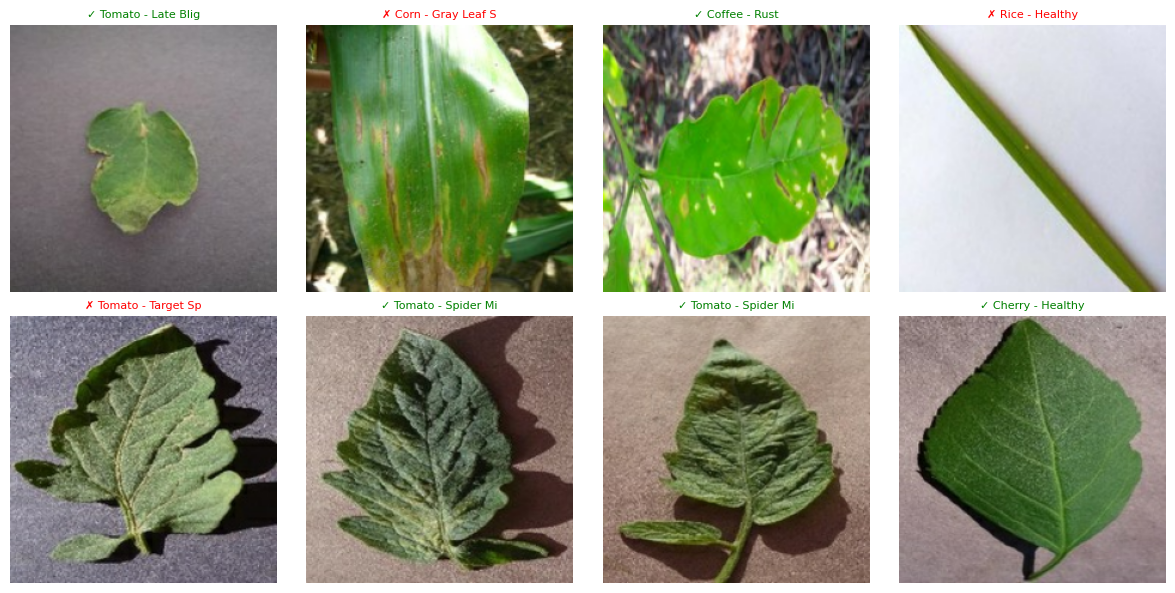

In [10]:
import matplotlib.pyplot as plt
xb, yb = next(iter(val_ds))
pred = model.predict(xb).argmax(1)
plt.figure(figsize=(12, 6))
for i in range(min(8, len(xb))):
    plt.subplot(2, 4, i+1); plt.imshow(xb[i].numpy().astype('uint8')); plt.axis('off')
    ok = pred[i] == yb[i].numpy()
    plt.title(('✓' if ok else '✗') + ' ' + labels[pred[i]]['label'][:18], color='green' if ok else 'red', fontsize=8)
plt.tight_layout(); plt.show()

## 10a. Export the trained model to disk (run FIRST)
Dumps the model to a TF SavedModel **before** installing the converter, so a pip
dependency change can't lose it. Loads the best checkpoint so trained weights are
guaranteed even after a disconnect.

In [11]:
# Load the BEST model saved during training (guarantees trained weights,
# not whatever is in memory after a possible disconnect). Falls back to memory.
try:
    model = tf.keras.models.load_model(CKPT); print('loaded best checkpoint ✓')
except Exception as e:
    print('no checkpoint, using in-memory model:', e)
model.export(f'{WORK}/sm')                                     # Keras 3 -> TF SavedModel
print('exported ✓  — now run 10b')

loaded best checkpoint ✓
INFO:tensorflow:Assets written to: /kaggle/working/sm/assets


INFO:tensorflow:Assets written to: /kaggle/working/sm/assets


Saved artifact at '/kaggle/working/sm'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 107), dtype=tf.float32, name=None)
Captures:
  138905566855440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138905566857936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138905566857552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138905566857360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138905566858512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138905566856592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138905566858128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138905566858320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138905566857168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138905566859472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138905566

## 10b. Convert to TensorFlow.js + get the file
Produces `web_model.zip` (model.json + *.bin + labels.json).
- **Colab:** it auto-downloads.
- **Kaggle:** find `web_model.zip` in the **Output** panel (right side), or the
  notebook's *Data → Output* after you *Save & Run All*.

**Unzip its contents into `frontend/models/`** — the app auto-detects it, no code change.

In [12]:
!pip install -q tensorflowjs
!tensorflowjs_converter --input_format=tf_saved_model --output_format=tfjs_graph_model {WORK}/sm {WORK}/web_model
import os, shutil
shutil.copy(f'{WORK}/labels.json', f'{WORK}/web_model/labels.json')
shutil.make_archive(f'{WORK}/web_model', 'zip', f'{WORK}/web_model')
size = sum(os.path.getsize(f'{WORK}/web_model/' + f) for f in os.listdir(f'{WORK}/web_model')) / 1e6
print('files:', os.listdir(f'{WORK}/web_model'), f'| {size:.1f} MB')
if IS_KAGGLE:
    print('✅ web_model.zip is in /kaggle/working — download it from the Output panel on the right.')
else:
    from google.colab import files; files.download(f'{WORK}/web_model.zip')

2026-07-11 12:36:51.675191: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783773411.699246     741 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783773411.708779     741 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783773411.728160     741 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783773411.728194     741 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783773411.728197     741 computation_placer.cc:177] computation placer alr